In [10]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom,crystal2cartesian
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green

import matplotlib.pyplot as plt
import pandas as pd
import time


In [20]:
# Input files
file_path = "./Ag/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=8.9684,poscar='POSCAR')
g_vec = model.g_vec

In [21]:
k_points = 200
custom_points = [
    [1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [-1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],     # Gamma
    [-1/3, -1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['M','Γ', 'M', 'K', 'Γ', 'K']

Calculating band structure...
Plotting band structure...


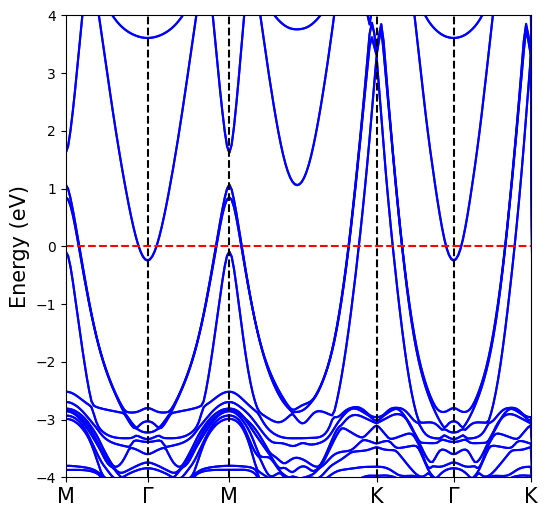

In [22]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


In [23]:
# Function to format time in a readable way
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f} seconds"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.2f} minutes"
    else:
        hours = seconds / 3600
        return f"{hours:.2f} hours"

/scratch/s.sevim/Dev/queer/queer/arpes.py:32: RuntimeWarning: invalid value encountered in sqrt
  kz = np.sqrt(C * (Ek + V0) - kx**2 - ky**2)


Energy calculations took 4.36 minutes
Data processing took 0.33 seconds
Plotting took 0.12 seconds
Total execution time: 4.36 minutes
Energy calculations took 4.50 minutes
Data processing took 0.31 seconds
Plotting took 0.07 seconds
Total execution time: 4.51 minutes
Energy calculations took 4.36 minutes
Data processing took 0.34 seconds
Plotting took 0.07 seconds
Total execution time: 4.36 minutes


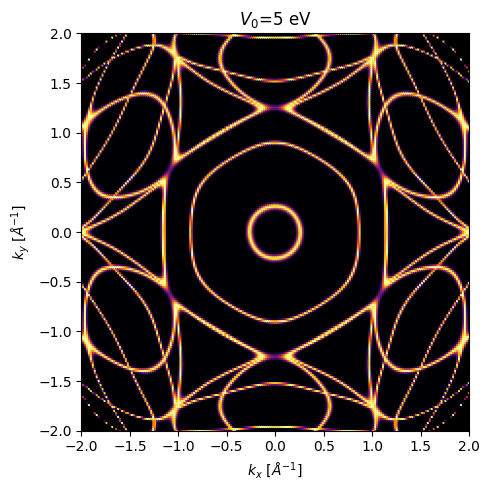

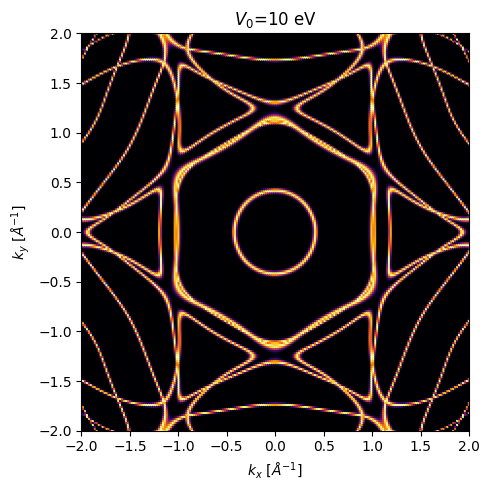

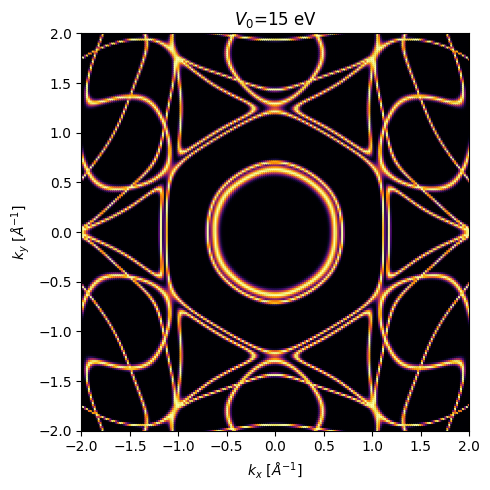

In [9]:
N = 200
factor = 4
binding_range = [0, 0.05]
binding_step = 0.1
photon_energy = 21.2
fermi_energy = 0
V0 = [5,10,15]
for v in V0:
    kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range, binding_step, v, N, factor)

    start_total = time.time()
    # Energy calculations
    start_energy = time.time()
    energy_dict = {}
    for i, j in kmesh_dict.items():
        kmesh = np.array(j)
        inv_kmesh = crystal2cartesian(kmesh, g_vec)
        band = model.calculate_energy(inv_kmesh)
        energy_dict[i] = band
    end_energy = time.time()
    print(f"Energy calculations took {format_time(end_energy - start_energy)}")

    # Data processing: mesh tiling to intensity calculation
    start_data = time.time()
    mesh_tile_dict = {}
    band_tile_dict = {}
    for i, j in kmesh_dict.items():
        kmesh = np.array(j)
        tile_mesh = []
        for k in range(energy_dict[i].shape[0]):
            tile_mesh.append(kmesh.T)
        mesh_tile = np.array(tile_mesh).reshape(-1, 3)
        mesh_tile_dict[i] = mesh_tile
        band_tile = energy_dict[i].flatten()
        band_tile_dict[i] = band_tile

    df_dict = {}
    for i, j in kmesh_dict.items():
        mesh_tile = mesh_tile_dict[i]
        band_tile = band_tile_dict[i]
        df = pd.DataFrame()
        df['kx'] = mesh_tile.T[0]
        df['ky'] = mesh_tile.T[1]
        df['kz'] = mesh_tile.T[2]
        df['e'] = band_tile
        df_dict[i] = df

    df_shift = {name: df.copy(deep=True) for name, df in df_dict.items()}
    energy_shift = df_shift[0].query('e<=0').max().e

    for i, j in df_shift.items():
        j.e -= energy_shift

    intensity_dict = {}
    for i, j in df_shift.items():
        j["I"] = np.exp(-((j.e + i)**2) / (2 * 0.1**2))
        group_max = j.loc[j.groupby(['kx', 'ky'])['I'].idxmax()]
        intensity_dict[i] = group_max
    end_data = time.time()
    print(f"Data processing took {format_time(end_data - start_data)}")
    start_plot = time.time()
    for i, j in intensity_dict.items():
        fig = plt.figure(figsize=(5, 5))
        plt.scatter(j.kx, j.ky, c=j.I, cmap='inferno', s=1)
        plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
        plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
        # plt.title(fr"${{E_B}}$={np.around(i,2)} eV")
        plt.title(fr"${{V_0}}$={v} eV")
        plt.gca().set_facecolor('black')
        plt.xlim(-2, 2)
        plt.ylim(-2, 2)
        plt.tight_layout()
        figure_path = f"./figs/V0_{V0}/{np.around(i,2)}.png"
        # plt.savefig(figure_path, dpi=300, bbox_inches='tight')
        # frame_files.append(figure_path)
        # plt.close(fig)  # Close figure to free memory instead of showing
    end_plot = time.time()
    print(f"Plotting took {format_time(end_plot - start_plot)}")

    # Total execution time
    end_total = time.time()
    print(f"Total execution time: {format_time(end_total - start_total)}")

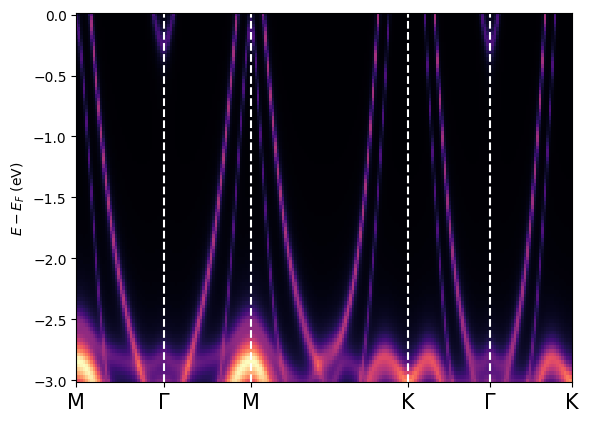

In [29]:
bands = model.calculate_energy(path)
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()


In [24]:
curved_path = arpes_path(path,g_vec,Ek=21.2,V0=15)
bands = model.calculate_energy(curved_path)

In [25]:
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))


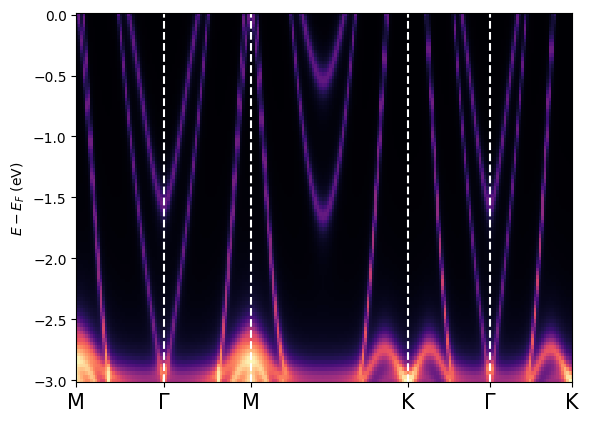

In [26]:
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()

In [27]:
v0_array = [15]
deltaE=np.linspace(0,-3,300)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(path,g_vec,Ek=21.2-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


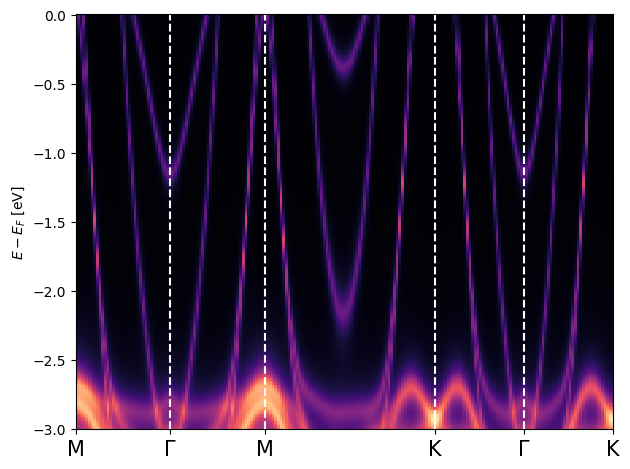

In [ ]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=sym, labels=labels, fontsize=15)
    plt.xlim(sym[0], sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    plt.savefig(f'figs/arpes_path/k_400/V0_{j}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()
